In [22]:
import pandas as pd 
import matplotlib.pyplot as plt
df = pd.read_csv(r"data\claims_train.csv")

In [23]:
print(f"The dataset has {len(df)} rows and {len(df.columns)} columns")

The dataset has 542410 rows and 12 columns


Text(0.5, 0, 'Claims')

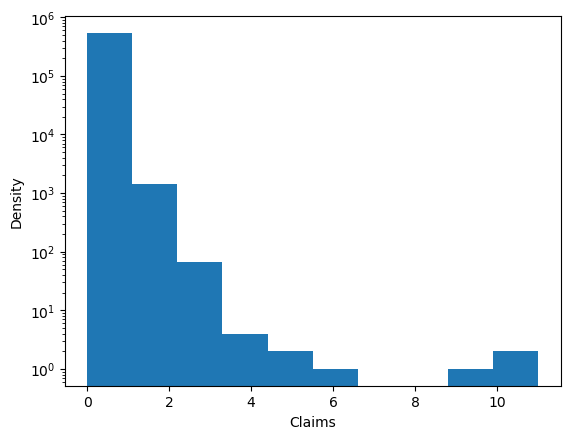

In [24]:
#plotting the claims distribution on a log scale
import matplotlib.pyplot as plt
plt.hist(df["ClaimNb"],log=True)
plt.ylabel("Density")
plt.xlabel("Claims")

In [25]:
mask = df["DrivAge"] > 80
df[mask]

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
133,3058998.0,1,1.00,D,7,7,82,62,B13,Regular,821,R24
134,4141235.0,0,1.00,E,5,19,81,50,B2,Regular,4116,R24
162,4185141.0,0,1.00,F,7,3,83,50,B1,Regular,15703,R11
166,2201364.0,0,1.00,D,4,8,81,57,B2,Regular,1268,R82
207,6055053.0,0,0.39,C,7,2,81,50,B12,Regular,354,R11
...,...,...,...,...,...,...,...,...,...,...,...,...
542122,3171878.0,0,1.00,E,7,13,81,50,B2,Regular,6729,R11
542159,2047718.0,0,1.00,C,5,7,85,50,B1,Regular,165,R53
542363,2047991.0,1,1.00,B,10,9,89,50,B1,Regular,91,R24
542376,6104302.0,0,0.71,C,5,1,83,50,B12,Diesel,133,R24


In [26]:
df[df["Exposure"] > 1]

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
272,1196421.0,0,1.03,D,6,4,51,50,B2,Diesel,1408,R73
1298,1194562.0,0,1.01,C,15,0,44,50,B11,Regular,162,R93
1767,2261449.0,0,1.06,B,7,1,66,50,B3,Diesel,91,R73
1990,1195469.0,0,1.01,C,6,8,43,91,B1,Diesel,269,R91
2209,2270505.0,0,1.03,D,5,3,25,76,B3,Regular,1535,R72
...,...,...,...,...,...,...,...,...,...,...,...,...
536377,1198636.0,0,1.22,D,5,3,40,64,B1,Diesel,962,R31
536528,1181521.0,0,1.03,C,10,13,64,54,B10,Regular,111,R26
536884,1196669.0,0,1.18,D,7,14,36,51,B2,Regular,1296,R24
541133,1197338.0,0,1.15,E,6,2,42,50,B10,Regular,3317,R93


(array([1.34054e+05, 4.13000e+02, 1.40000e+01, 0.00000e+00, 1.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00]),
 array([ 0. ,  1.1,  2.2,  3.3,  4.4,  5.5,  6.6,  7.7,  8.8,  9.9, 11. ]),
 <BarContainer object of 10 artists>)

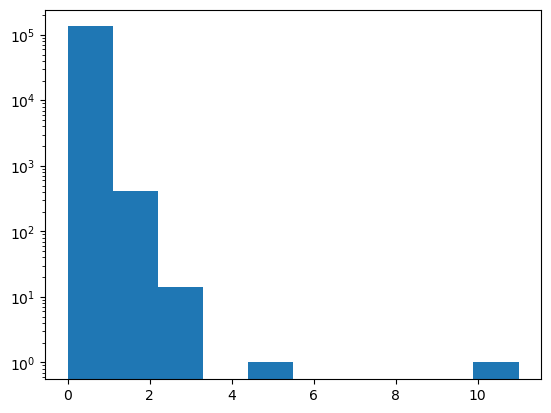

In [27]:
df1 = df[df["Exposure"] == 1]
x = df1["ClaimNb"]

plt.hist(x,log=True)

In [28]:
df.head(30)

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,2122523.0,0,0.43,D,7,18,36,95,B1,Regular,1054,R24
1,3173420.0,0,0.10,D,7,17,80,95,B2,Regular,598,R25
2,1188619.0,0,0.33,E,7,3,36,76,B6,Regular,4172,R82
3,31400.0,0,0.56,A,5,4,73,52,B13,Diesel,15,R24
4,3138755.0,0,0.27,E,8,0,37,50,B11,Diesel,3021,R53
5,4117349.0,0,1.00,A,8,7,33,56,B2,Diesel,45,R24
6,3186358.0,0,1.00,D,7,15,39,50,B2,Diesel,515,R54
7,2283257.0,0,0.08,E,7,5,46,50,B1,Regular,6736,R11
8,4130781.0,0,0.06,C,10,14,38,50,B5,Diesel,164,R82
9,1110520.0,0,0.26,D,4,6,21,95,B6,Regular,1284,R25


In [29]:
df.drop(labels="IDpol",axis=1)

,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,0,0.43,D,7,18,36,95,B1,Regular,1054,R24
1,0,0.10,D,7,17,80,95,B2,Regular,598,R25
2,0,0.33,E,7,3,36,76,B6,Regular,4172,R82
3,0,0.56,A,5,4,73,52,B13,Diesel,15,R24
4,0,0.27,E,8,0,37,50,B11,Diesel,3021,R53
...,...,...,...,...,...,...,...,...,...,...,...
542405,0,0.20,D,6,10,32,76,B2,Diesel,1314,R24
542406,0,0.06,D,10,14,34,60,B5,Diesel,685,R72
542407,0,0.34,C,6,8,32,95,B5,Diesel,242,R82
542408,0,0.72,E,9,7,39,72,B2,Regular,3301,R73


In [30]:
df_drop_cat = df.drop(labels=["Area","VehBrand","VehGas","Region","IDpol"],axis=1)


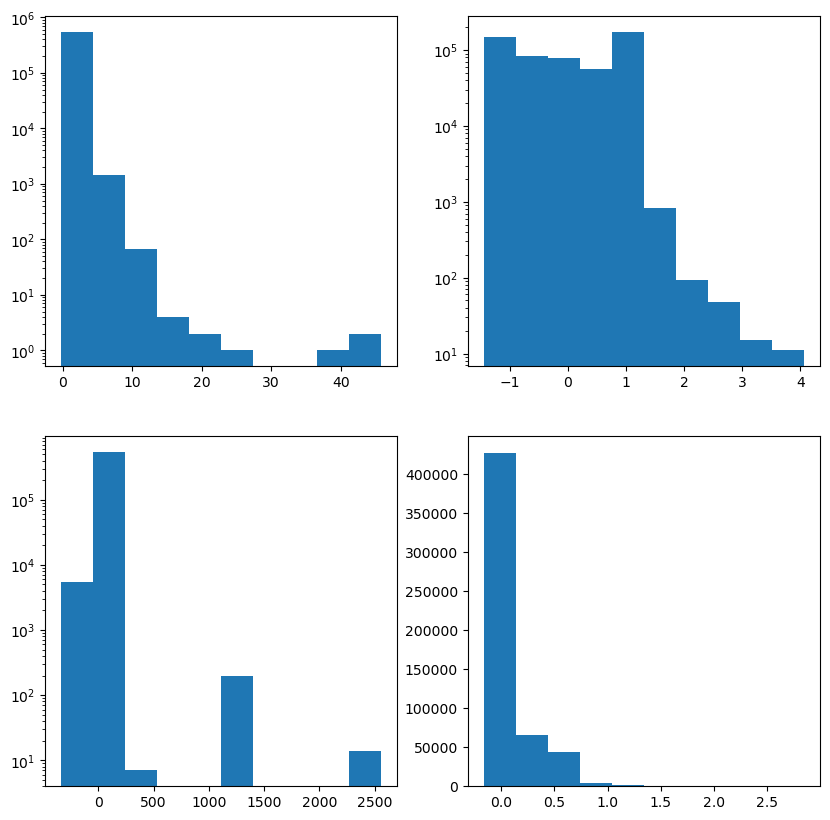

In [31]:
import numpy as np
mean_claims = np.mean(df["ClaimNb"])
std_claims = np.std(df["ClaimNb"])

df_drop_cat["ZClaimNB"] = (df_drop_cat["ClaimNb"] - mean_claims)/std_claims

mean_exposures = np.mean(df["Exposure"])
std_exposures = np.std(df["Exposure"])

df_drop_cat["ZExposure"] = (df_drop_cat["Exposure"] - mean_exposures)/std_exposures

df_drop_cat["Claim per Exposure"] = df_drop_cat["ZClaimNB"]/df_drop_cat["ZExposure"]

mean_bonus = np.mean(df["BonusMalus"])
std_bonus = np.mean(df["BonusMalus"])

df_drop_cat["ZBonusMalus"] = (df_drop_cat["BonusMalus"] - mean_bonus)/std_bonus

fig = plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
plt.hist(df_drop_cat["ZClaimNB"],log=True)
plt.subplot(2,2,2)
plt.hist(df_drop_cat["ZExposure"],log=True)
plt.subplot(2,2,3)
plt.hist(df_drop_cat["Claim per Exposure"],log=True)
plt.subplot(2,2,4)
plt.hist(df_drop_cat["ZBonusMalus"],log=False)
plt.show()


In [32]:
#pd.plotting.scatter_matrix(df_drop_cat)

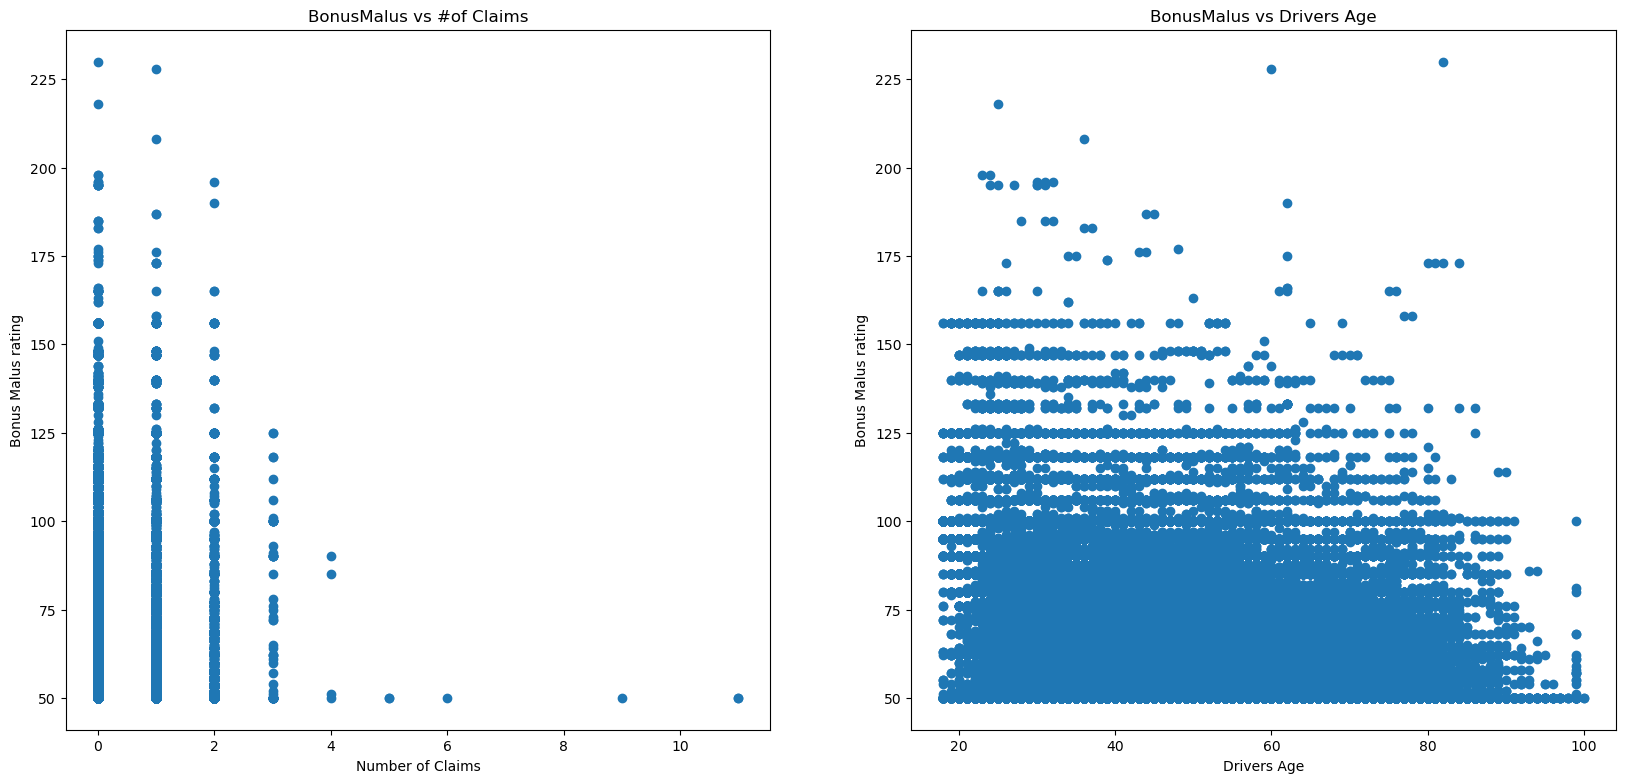

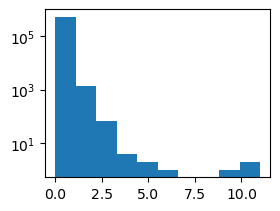

In [33]:
fig = plt.figure(figsize=(20,20))
#for i in range(len(df_drop_cat.columns)):

plt.subplot(2,2,1)
plt.scatter(df["ClaimNb"],df["BonusMalus"])
plt.xlabel("Number of Claims")
plt.ylabel("Bonus Malus rating")
plt.title("BonusMalus vs #of Claims")

plt.subplot(2,2,2)
plt.scatter(df["DrivAge"],df["BonusMalus"])
plt.xlabel("Drivers Age")
plt.ylabel("Bonus Malus rating")
plt.title("BonusMalus vs Drivers Age")
plt.show()

plt.subplot(2,2,3)
plt.hist(df["ClaimNb"],log=True)
plt.show()


In [34]:
claimsabove0 = df[df["ClaimNb"] > 0]

Text(0, 0.5, 'Density')

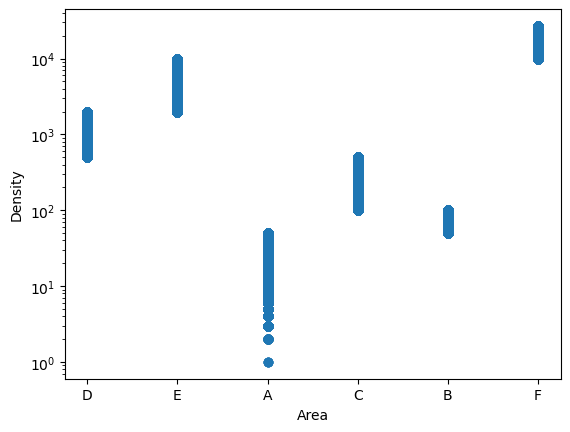

In [35]:
df = df[["Area","Density","Region"]]
import matplotlib.pyplot as plt

plt.scatter(df["Area"],df["Density"])
plt.yscale('log')
plt.xlabel("Area")
plt.ylabel("Density")

In [36]:
df.shape

(542410, 3)

In [63]:
import numpy as np
data = {
    "Hours Studied" : [2,3,4,5,6,7,8,9,10,10],
    "Sleep_hours" : [8,7,9,5,8,7,6,7,4,9],
    "Exam Score" : [55,60,70,65,80,85,82,90,75,95]
}

df = pd.DataFrame(data)
X = df[["Hours Studied","Sleep_hours"]]
y = df["Exam Score"]


In [64]:
def rss(data_points:list):
    """ For a given list of data points in a region, 
        this function returns the residual sum of squares for that region"""
    RSS = 0
    region_mean = np.mean(data_points)
    for i in range(len(data_points)):
        RSS += (data_points[i] - region_mean)**2 #For each region our prediction is the mean of points in that R
    return RSS



def best_split(X:pd.DataFrame,Y:pd.DataFrame):
    """For given training data, all in the same region, this function
        returns the best feature to split on as well as the best threshold, 
        i.e one that minimizes RSS at that point"""
    
    n_samples,n_features = X.shape
    
    best_rss = float('inf')

    for i in range(n_features):  #loop over all features to find the best one
        feature = X.columns[i]
        splits = np.unique(X[feature]) # for each feature consider all possible splits
        

        for j in range(len(splits)-1): #loops over all possible splits in that feature
            split = (splits[j] + splits[j+1]) / 2
            
            #split the data on both X and Y 
            left_region = X[feature] < split
            right_region = X[feature] >= split
            
            left_labels = y[left_region]
            right_labels = y[right_region]
            
            #calculate the RSS and add it for both regions
            current_rss = rss(list(left_labels)) + rss(list(right_labels))
            
            #if we have found a RSS less than previous best then we have a new lowest RSS
            if current_rss < best_rss:
                best_rss = current_rss
                best = [feature,split]
    
    return best
def build_tree(x,y):
    #We need to recursively build a tree with some stopping conditions

    #given our training data find the best split 
    best_feature, best = best_split(x,y)
    left_region = x[best_feature] < best
    right_region = x[best_feature] >= best
    print(y[left_region])
    return x[left_region]

build_tree(X,y)

0    55
1    60
2    70
3    65
Name: Exam Score, dtype: int64


,Hours Studied,Sleep_hours
0,2,8
1,3,7
2,4,9
3,5,5


In [65]:
import numpy as np
import pandas as pd
data = {
    "Hours Studied" : [2,3,4,5,6,7,8,9,10,10],
    "Sleep_hours" : [8,7,9,5,8,7,6,7,4,9],
    "Exam Score" : [55,60,70,65,80,85,82,90,75,95]
}

df = pd.DataFrame(data)
X_train = df[["Hours Studied","Sleep_hours"]]
y_train = df["Exam Score"]

In [66]:
from sourceCode.decisionTree.decisiontree import DecisionTreeRegressor

dt = DecisionTreeRegressor(2)

In [67]:
data_test = {
    "Hours Studied" : [2],
    "Sleep_hours" : [8]
}

df = pd.DataFrame(data_test)
X_test = df[["Hours Studied","Sleep_hours"]]

In [68]:
dt.fit(X_train,y_train)

In [71]:
dt.traverse(data_test,dt.root)

np.float64(57.5)

In [44]:
import sklearn
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(criterion='squared_error',max_depth=2)

dt.fit(X_train,y_train)
dt.predict(X_test)

array([57.5])

In [6]:
import pandas as pd
df = pd.read_csv(r"data\claims_train_final.csv")

In [19]:
df

,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,0,0.43,D,7,18,36,95,B1,Regular,1054,R24
1,0,0.10,D,7,17,80,95,B2,Regular,598,R25
2,0,0.33,E,7,3,36,76,B6,Regular,4172,R82
3,0,0.56,A,5,4,73,52,B13,Diesel,15,R24
4,0,0.27,E,8,0,37,50,B11,Diesel,3021,R53
...,...,...,...,...,...,...,...,...,...,...,...
541411,0,0.20,D,6,10,32,76,B2,Diesel,1314,R24
541412,0,0.06,D,10,14,34,60,B5,Diesel,685,R72
541413,0,0.34,C,6,8,32,95,B5,Diesel,242,R82
541414,0,0.72,E,9,7,39,72,B2,Regular,3301,R73


array([[<Axes: xlabel='ClaimNb', ylabel='ClaimNb'>,
        <Axes: xlabel='Exposure', ylabel='ClaimNb'>,
        <Axes: xlabel='VehPower', ylabel='ClaimNb'>,
        <Axes: xlabel='DrivAge', ylabel='ClaimNb'>,
        <Axes: xlabel='BonusMalus', ylabel='ClaimNb'>,
        <Axes: xlabel='Density', ylabel='ClaimNb'>],
       [<Axes: xlabel='ClaimNb', ylabel='Exposure'>,
        <Axes: xlabel='Exposure', ylabel='Exposure'>,
        <Axes: xlabel='VehPower', ylabel='Exposure'>,
        <Axes: xlabel='DrivAge', ylabel='Exposure'>,
        <Axes: xlabel='BonusMalus', ylabel='Exposure'>,
        <Axes: xlabel='Density', ylabel='Exposure'>],
       [<Axes: xlabel='ClaimNb', ylabel='VehPower'>,
        <Axes: xlabel='Exposure', ylabel='VehPower'>,
        <Axes: xlabel='VehPower', ylabel='VehPower'>,
        <Axes: xlabel='DrivAge', ylabel='VehPower'>,
        <Axes: xlabel='BonusMalus', ylabel='VehPower'>,
        <Axes: xlabel='Density', ylabel='VehPower'>],
       [<Axes: xlabel='ClaimNb', y

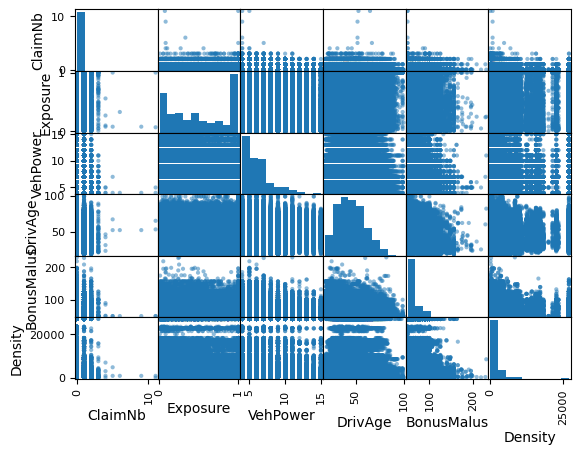

In [20]:
#Data Visualisation

df_reduced = df[["ClaimNb","Exposure","VehPower","DrivAge","BonusMalus","Density"]]

pd.plotting.scatter_matrix(df_reduced)

C:\Users\khatt\AppData\Local\Temp\ipykernel_23600\2657414043.py:15: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='viridis')


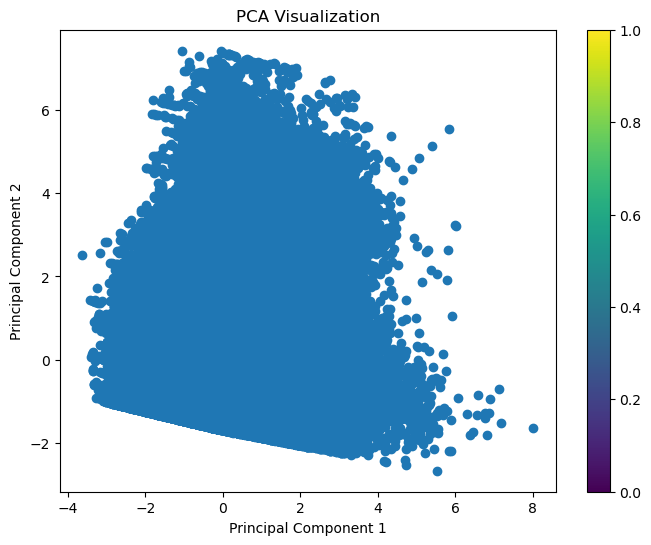

In [22]:
#First Attempt at PCA :(
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

target = df_reduced["ClaimNb"]
data = df_reduced.drop("ClaimNb",axis=1)

scaled_data = StandardScaler().fit_transform(data)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_data)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization')
plt.colorbar(scatter)
plt.show()

In [29]:
a = df[["Area","Density"]].groupby(by=df["Area"]).max()

In [40]:
b = df[["Area","Density"]].groupby(by=df["Area"]).min()
b

,Area,Density
Area,,
A,A,1
B,B,50
C,C,100
D,D,500
E,E,2001
F,F,10008


In [44]:
new_data = pd.DataFrame()

In [45]:
new_data["Area"] = a["Area"]
new_data["Density_min"] = b["Density"]
new_data["Density_max"] = a["Density"]
new_data

,Area,Density_min,Density_max
Area,,,
A,A,1,50
B,B,50,100
C,C,100,500
D,D,500,1993
E,E,2001,9850
F,F,10008,27000


In [56]:
df_reduced = df[["Density","Area"]]
df_reduced = df_reduced.sort_values(by="Area")

Text(0.5, 1.0, 'Area vs Density')

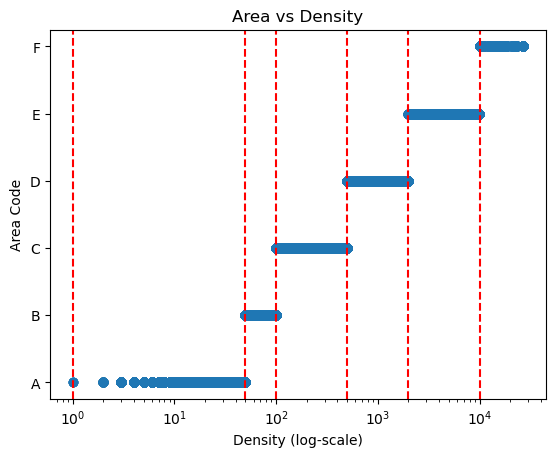

In [ ]:
plt.scatter(df_reduced["Density"],df_reduced["Area"])
plt.xscale('log')
plt.axvline(x=1, color='red', linestyle='--')
plt.axvline(x=50, color='red', linestyle='--')
plt.axvline(x=100, color='red', linestyle='--')
plt.axvline(x=500, color='red', linestyle='--')
plt.axvline(x=2001, color='red', linestyle='--')
plt.axvline(x=10008, color='red', linestyle='--')
plt.xlabel("Density (log-scale)")
plt.ylabel("Area Code")
plt.title("Area vs Density")


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"data\claims_train_final.csv")


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,2122523.0,0,0.43,D,7,18,36,95,B1,Regular,1054,R24
1,3173420.0,0,0.10,D,7,17,80,95,B2,Regular,598,R25
2,1188619.0,0,0.33,E,7,3,36,76,B6,Regular,4172,R82
3,31400.0,0,0.56,A,5,4,73,52,B13,Diesel,15,R24
4,3138755.0,0,0.27,E,8,0,37,50,B11,Diesel,3021,R53
...,...,...,...,...,...,...,...,...,...,...,...,...
541011,2063494.0,0,0.20,D,6,10,32,76,B2,Diesel,1314,R24
541012,4164964.0,0,0.06,D,10,14,34,60,B5,Diesel,685,R72
541013,3078112.0,0,0.34,C,6,8,32,95,B5,Diesel,242,R82
541014,1012927.0,0,0.72,E,9,7,39,72,B2,Regular,3301,R73


(array([4.94643e+05, 2.59670e+04, 8.09900e+03, 3.08300e+03, 2.21000e+02,
        9.00300e+03]),
 array([1.00000000e+00, 4.50083333e+03, 9.00066667e+03, 1.35005000e+04,
        1.80003333e+04, 2.25001667e+04, 2.70000000e+04]),
 <BarContainer object of 6 artists>)

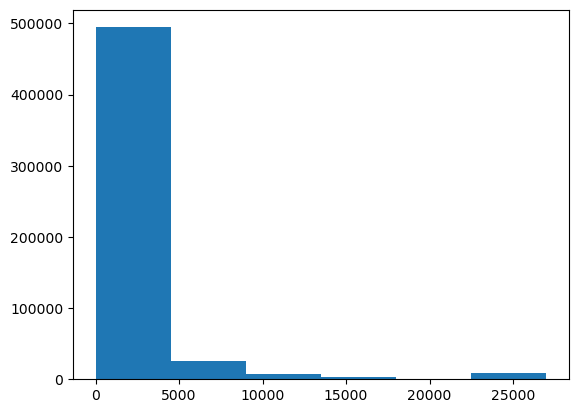

In [10]:
#fig = plt.figure(figsize=(10,10))
plt.hist(df["Density"],bins=6)